In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"namakpaara","key":"b6815ca05d17fe0745fdf48abda673e3"}'}

In [3]:
# Step 1: Set up Kaggle API credentials
import os
os.makedirs('/root/.kaggle', exist_ok=True)

# Assuming 'kaggle.json' is uploaded to the root directory of Colab environment
!cp kaggle.json /root/.kaggle/
os.chmod('/root/.kaggle/kaggle.json', 600)

In [4]:
!kaggle competitions download -c isic-2024-challenge

100% 1.99G/2.00G [00:24<00:00, 83.6MB/s]
100% 2.00G/2.00G [00:24<00:00, 87.5MB/s]


In [5]:
!unzip isic-2024-challenge.zip

Streaming output truncated to the last 5000 lines.
  inflating: train-image/image/ISIC_9874656.jpg  
  inflating: train-image/image/ISIC_9874659.jpg  
  inflating: train-image/image/ISIC_9874663.jpg  
  inflating: train-image/image/ISIC_9874742.jpg  
  inflating: train-image/image/ISIC_9874751.jpg  
  inflating: train-image/image/ISIC_9874803.jpg  
  inflating: train-image/image/ISIC_9874805.jpg  
  inflating: train-image/image/ISIC_9874832.jpg  
  inflating: train-image/image/ISIC_9874878.jpg  
  inflating: train-image/image/ISIC_9874897.jpg  
  inflating: train-image/image/ISIC_9874925.jpg  
  inflating: train-image/image/ISIC_9874931.jpg  
  inflating: train-image/image/ISIC_9874939.jpg  
  inflating: train-image/image/ISIC_9874940.jpg  
  inflating: train-image/image/ISIC_9874963.jpg  
  inflating: train-image/image/ISIC_9874987.jpg  
  inflating: train-image/image/ISIC_9875007.jpg  
  inflating: train-image/image/ISIC_9875010.jpg  
  inflating: train-image/image/ISIC_9875033.jpg  

In [6]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from imblearn.over_sampling import SMOTE
import seaborn as sns

In [7]:
# Paths to dataset
metadata_path = '/content/train-metadata.csv'
image_folder_path = '/content/train-image/image'

In [8]:
# Load metadata
metadata = pd.read_csv(metadata_path, low_memory=False)
print("Metadata Loaded:")
print(metadata.head())

Metadata Loaded:
        isic_id  target  patient_id  age_approx   sex anatom_site_general  \
0  ISIC_0015670       0  IP_1235828        60.0  male     lower extremity   
1  ISIC_0015845       0  IP_8170065        60.0  male           head/neck   
2  ISIC_0015864       0  IP_6724798        60.0  male     posterior torso   
3  ISIC_0015902       0  IP_4111386        65.0  male      anterior torso   
4  ISIC_0024200       0  IP_8313778        55.0  male      anterior torso   

   clin_size_long_diam_mm          image_type tbp_tile_type   tbp_lv_A  ...  \
0                    3.04  TBP tile: close-up     3D: white  20.244422  ...   
1                    1.10  TBP tile: close-up     3D: white  31.712570  ...   
2                    3.40  TBP tile: close-up        3D: XP  22.575830  ...   
3                    3.22  TBP tile: close-up        3D: XP  14.242329  ...   
4                    2.73  TBP tile: close-up     3D: white  24.725520  ...   

    lesion_id  iddx_full  iddx_1  iddx_2  idd

In [9]:
metadata

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401054,ISIC_9999937,0,IP_1140263,70.0,male,anterior torso,6.80,TBP tile: close-up,3D: XP,22.574335,...,IL_9520694,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999988
401055,ISIC_9999951,0,IP_5678181,60.0,male,posterior torso,3.11,TBP tile: close-up,3D: white,19.977640,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999820
401056,ISIC_9999960,0,IP_0076153,65.0,female,anterior torso,2.05,TBP tile: close-up,3D: XP,17.332567,...,IL_9852274,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999416
401057,ISIC_9999964,0,IP_5231513,30.0,female,anterior torso,2.80,TBP tile: close-up,3D: XP,22.288570,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000


In [10]:
print("\nOriginal Class Distribution:")
print(metadata['target'].value_counts())



Original Class Distribution:
target
0    400666
1       393
Name: count, dtype: int64


<Axes: xlabel='target', ylabel='count'>

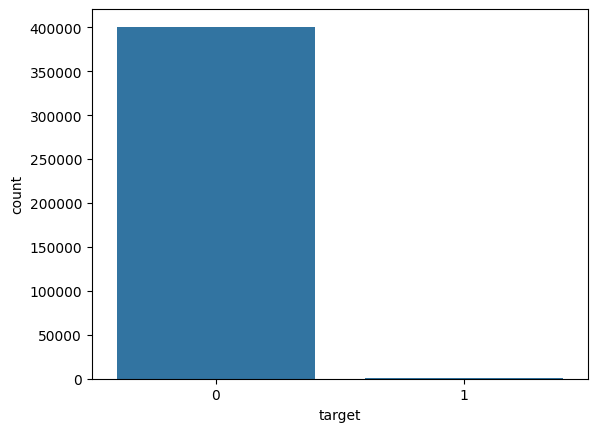

In [11]:
sns.countplot(data=metadata, x='target')

We can see there is high imbalance in the data so we should perform SMOTE to balance it but since there is hardware limitations we will be performing downsampling.

In [12]:
from sklearn.utils import resample

In [13]:
# Perform downsampling to balance the dataset (equal number of malignant and benign samples)
malignant = metadata[metadata['target'] == 1]
benign = metadata[metadata['target'] == 0]

In [14]:
benign_downsample=resample(benign,replace=True, n_samples=len(malignant),random_state=42)

In [15]:
downsampled_data=pd.concat([malignant,benign_downsample])

In [16]:
# Check the distribution after downsampling
print("Downsampled Data Distribution:")
print(downsampled_data['target'].value_counts())

Downsampled Data Distribution:
target
1    393
0    393
Name: count, dtype: int64


Since we have hardware limitations we have to perform downsampling technique but its not recommended as by downsampling we may loose some important information about the data.

In [17]:
# Image generator to load and preprocess images in batches
def image_generator(metadata, image_folder_path, batch_size=32):
    X_batch = []
    y_batch = []

    for index, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Loading Images"):
        image_name = f"{row['isic_id']}.jpg"
        label = row['target']
        image_path = os.path.join(image_folder_path, image_name)

        # Load and preprocess image
        if os.path.exists(image_path):
            image = load_img(image_path, color_mode='grayscale', target_size=(64, 64))
            image_array = img_to_array(image)
            image_flattened = image_array.flatten()

            X_batch.append(image_flattened)
            y_batch.append(label)

        # Yield batch if it's full
        if len(X_batch) == batch_size:
            yield np.array(X_batch), np.array(y_batch)
            X_batch, y_batch = [], []  # Reset the batch lists for the next batch

In [18]:
# Prepare data for training and evaluation using downsampled data
# Split the data into training and testing sets
X = []
y = []

In [19]:
for index, row in downsampled_data.iterrows():
    image_name = f"{row['isic_id']}.jpg"
    label = row['target']
    image_path = os.path.join(image_folder_path, image_name)

    if os.path.exists(image_path):
        # Load and preprocess the image
        image = load_img(image_path, color_mode='grayscale', target_size=(64, 64))
        image_array = img_to_array(image)
        image_flattened = image_array.flatten()

        X.append(image_flattened)
        y.append(label)


In [20]:
# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

In [21]:
X

array([[135., 131., 133., ..., 104., 100.,  94.],
       [  1.,   1.,   1., ..., 135., 143., 146.],
       [139., 137., 154., ..., 167., 164., 163.],
       ...,
       [142., 140., 142., ..., 131., 130., 131.],
       [ 83.,  79.,  86., ...,  79.,  70.,  66.],
       [130., 117., 114., ..., 140., 133., 124.]], dtype=float32)

In [22]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [23]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
# Initialize a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [25]:
# Train the model on the training data
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [26]:
train_preds=model.predict(X_train)

In [27]:
#getting classification report
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_train,train_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       312
           1       1.00      1.00      1.00       316

    accuracy                           1.00       628
   macro avg       1.00      1.00      1.00       628
weighted avg       1.00      1.00      1.00       628



In [28]:
test_preds_rand=model.predict(X_test)

In [29]:
#getting classification report
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,test_preds_rand))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74        81
           1       0.73      0.70      0.72        77

    accuracy                           0.73       158
   macro avg       0.73      0.73      0.73       158
weighted avg       0.73      0.73      0.73       158



We can see the model os performing like 100 % in training and like 73% on testing data. We will perform hyperparameter tuning to see if we can improve the performance on testing data.

In [30]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn import metrics
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=50,
                                   cv=2, random_state=42, n_jobs=-1, verbose=2)

random_search.fit(X_train, y_train)

	#to see the suitable params
random_search.best_params_


Fitting 2 folds for each of 50 candidates, totalling 100 fits


{'bootstrap': False,
 'max_depth': 18,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 133}

In [31]:
test_pred_rand_hyper=random_search.predict(X_test)

In [32]:
#getting classification report
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,test_pred_rand_hyper))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76        81
           1       0.75      0.73      0.74        77

    accuracy                           0.75       158
   macro avg       0.75      0.75      0.75       158
weighted avg       0.75      0.75      0.75       158



We can see after hyperparameter tuning the F1Score increased as it was an unbalanced dataset.

### Making the AUC ROC

Text(0, 0.5, 'True Positive Rate')

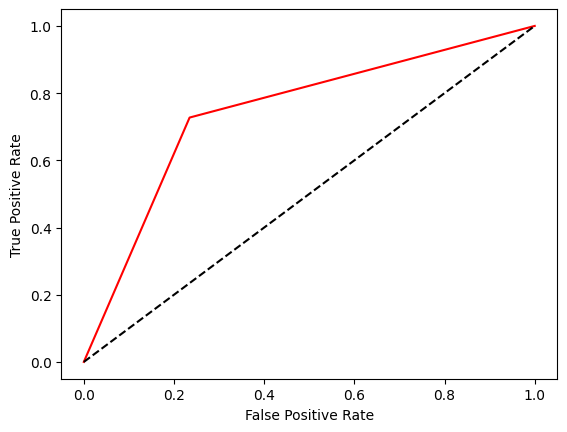

In [33]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_pred_rand_hyper)

auc = roc_auc_score(y_test, test_pred_rand_hyper)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

We can see the AUC is between 0.7-0.8 which means it's a fair model.

# XGBOOST

In [34]:
! pip install xgboost

In [35]:
from xgboost import XGBClassifier

In [36]:
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [37]:
train_preds_xgb=model.predict(X_train)

In [38]:
#getting classification report
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_train,train_preds_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       312
           1       1.00      1.00      1.00       316

    accuracy                           1.00       628
   macro avg       1.00      1.00      1.00       628
weighted avg       1.00      1.00      1.00       628



In [39]:
test_preds_xgb=model.predict(X_test)

In [40]:
#getting classification report
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,test_preds_xgb))

              precision    recall  f1-score   support

           0       0.70      0.77      0.73        81
           1       0.73      0.66      0.69        77

    accuracy                           0.72       158
   macro avg       0.72      0.71      0.71       158
weighted avg       0.72      0.72      0.71       158



We will do the hyperparameter tuning to see if we can improve the performance of the model.

In [43]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score

# Define the model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300, 400,500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.001,0.0001],
    'max_depth': [3, 5, 7, 10,9],
    'subsample': [0.4,0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0,0.5],
    'gamma': [0, 0.1, 0.2, 0.3,0.4],
    'reg_alpha': [0, 0.1, 0.5,0.7],
    'reg_lambda': [1, 1.5, 2,0]
}

# Use RandomizedSearchCV for faster tuning (GridSearchCV for exhaustive search)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,  # Number of different combinations to try (you can adjust this)
    scoring='accuracy',  # Adjust based on your metric
    cv=2,  # 3-fold cross-validation
    verbose=1,
    n_jobs=-1,  # Use all available cores
    random_state=42
)


In [44]:
random_search.fit(X_train, y_train)


Fitting 2 folds for each of 50 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:47:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0,
                                                             0.5],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.001, 0.0001],
                                        'max_depth': [3, 5, 7, 10, 9],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 0.7],
                                        'reg_lambda': [1, 1.5, 2, 0],
                                        'subsample': [0.4, 0.6, 0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [45]:
best_params = random_search.best_params_
best_score = random_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)


Best Parameters: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.5}
Best Score: 0.7117834394904459


In [46]:
xgb = XGBClassifier(subsample= 0.6, reg_lambda= 1.5, reg_alpha= 0.1, n_estimators= 200, max_depth= 9, learning_rate= 0.2, gamma= 0.1, colsample_bytree= 0.5)

In [47]:
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [48]:
test_preds_xgb_hyper= xgb.predict(X_test)

In [49]:
#getting classification report
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,test_preds_xgb_hyper))

              precision    recall  f1-score   support

           0       0.74      0.70      0.72        81
           1       0.70      0.74      0.72        77

    accuracy                           0.72       158
   macro avg       0.72      0.72      0.72       158
weighted avg       0.72      0.72      0.72       158



Text(0, 0.5, 'True Positive Rate')

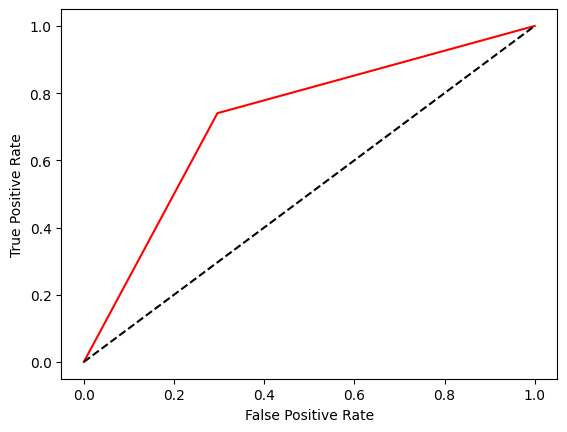

In [50]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_preds_xgb_hyper)

auc = roc_auc_score(y_test, test_preds_xgb_hyper)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

We can see the AUC of XGB is almost same as random forest which is between 0.6 to 0.8 which means its a fine model.